# 📊 Air Quality Index (AQI) Prediction in India: A Production-Grade Machine Learning Pipeline
**Author:** Senior Data Scientist & ML Engineer  
**Dataset:** Daily Air Quality Data in India (2015 - 2020)  
**Task:** Regression (Predicting continuous AQI values) & Classification (Predicting AQI Bucket)

---

## 📖 1. Project Overview & Background
Air pollution is a major environmental and public health concern globally. In India, the National Air Quality Index (AQI) is used to communicate the status of air quality to the public. The AQI is determined based on the concentration of key air pollutants:
- **Particulate Matter:** $PM_{2.5}$ and $PM_{10}$
- **Nitrogen Oxides:** $NO$, $NO_2$, $NO_x$
- **Ammonia:** $NH_3$
- **Carbon Monoxide:** $CO$
- **Sulfur Dioxide:** $SO_2$
- **Ozone:** $O_3$
- **Organic Pollutants:** Benzene, Toluene, Xylene

### 🎯 Objectives:
1. **Comprehensive Exploratory Data Analysis (EDA)** to understand pollutant distributions, correlations, temporal trends, and city-wise variations.
2. **Robust Preprocessing & Feature Engineering** that avoids data leakage, scales features, and creates high-value domain features.
3. **Multi-Model Regression Benchmarking** utilizing 15+ models (Linear, Distance-Based, Support Vector, Tree-Based, Gradient Boosting, Voting, and Stacking).
4. **Hyperparameter Tuning & Interpretation** of the best performing model using Grid Search and Permutation Importance.


## 🛠️ 2. Environment Setup & Library Ingestion
We begin by importing the necessary libraries for data manipulation, visualization, modeling, and evaluation. We configure plotting styles to ensure modern, premium graphics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
from tqdm import tqdm

# Setting visualization configurations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'font.family': 'sans-serif'
})
warnings.filterwarnings('ignore')

# Modeling & preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Regression Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor,
    AdaBoostRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor,
    VotingRegressor, StackingRegressor
)
import xgboost as xgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor


## 📥 3. Dataset Loading
We load the dataset using `kagglehub` to download the latest version, then read the `city_day.csv` file containing city-level daily air quality measurements.


In [2]:
import kagglehub

# Download latest version of the Air Quality Data in India dataset
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")
print("Path to dataset files:", path)

# Load daily city data
city_day_path = os.path.join(path, 'city_day.csv')
city_day = pd.read_csv(city_day_path)
print(f"Dataset loaded successfully with shape: {city_day.shape}")


Path to dataset files: C:\Users\Naseer\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12
Dataset loaded successfully with shape: (29531, 16)


## 🔍 4. Exploratory Data Analysis (EDA)
In this section, we examine the dataset structure, missing values, duplicates, descriptive statistics, outlier profiles, temporal trends, and correlation structures.


In [3]:
# 1. Dataset Overview & Shape
print("=== Dataset Shape ===")
print(city_day.shape)

print("\n=== Data Types & Info ===")
print(city_day.info())

print("\n=== Duplicate Rows ===")
duplicates = city_day.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


=== Dataset Shape ===
(29531, 16)

=== Data Types & Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None

=== Duplicate Rows ===
Number of 

### 📊 4.1 Missing Values Analysis
We analyze the distribution of missing values across features. Since air monitoring stations can experience downtime, missing values are common in environmental sensor data.


=== Missing Values Summary ===


        Column  Missing_Count  Missing_Percentage
13      Xylene          18109           61.322001
3         PM10          11140           37.723071
7          NH3          10328           34.973418
12     Toluene           8041           27.229014
11     Benzene           5623           19.041008
14         AQI           4681           15.851139
15  AQI_Bucket           4681           15.851139
2        PM2.5           4598           15.570079
6          NOx           4185           14.171549
10          O3           4022           13.619586
9          SO2           3854           13.050692
5          NO2           3585           12.139785
4           NO           3582           12.129626
8           CO           2059            6.972334
1         Date              0            0.000000
0         City              0            0.000000


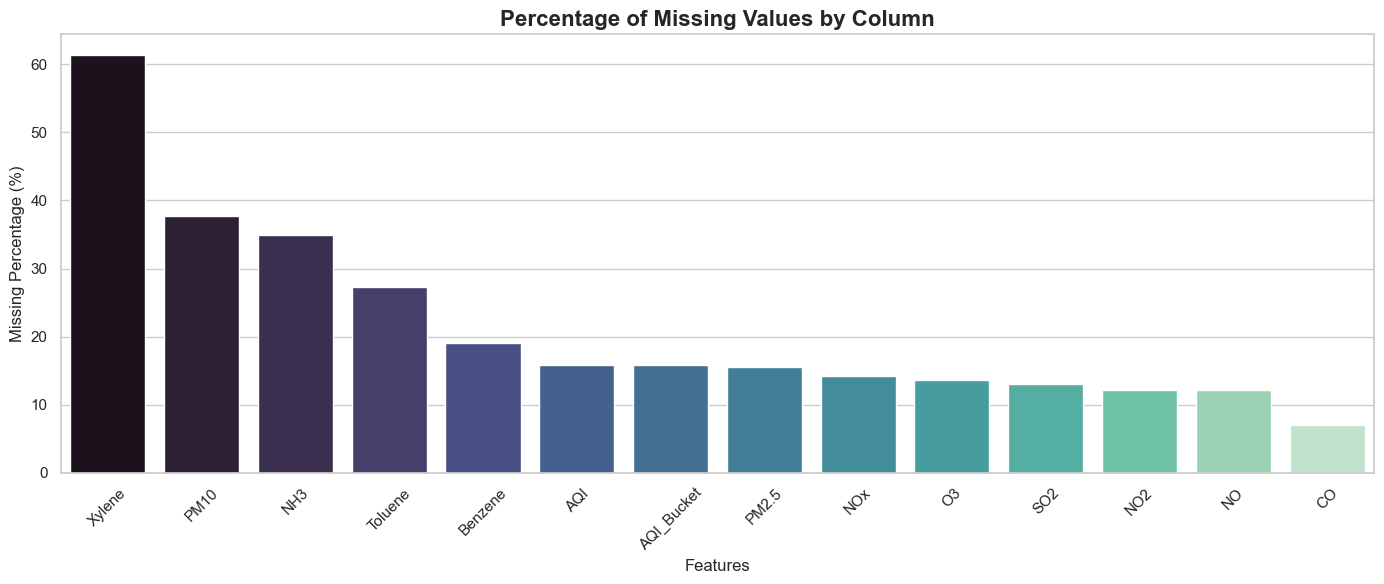

In [4]:
# Missing values count and percentage
missing_df = city_day.isnull().sum().reset_index()
missing_df.columns = ['Column', 'Missing_Count']
missing_df['Missing_Percentage'] = (missing_df['Missing_Count'] / len(city_day)) * 100
missing_df = missing_df.sort_values(by='Missing_Percentage', ascending=False)

print("=== Missing Values Summary ===")
print(missing_df)

# Visualizing missing values
plt.figure(figsize=(14, 6))
sns.barplot(data=missing_df[missing_df['Missing_Count'] > 0], x='Column', y='Missing_Percentage', palette='mako')
plt.title('Percentage of Missing Values by Column', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


> **Insight:** Xylene has the highest missing percentage (~61%), followed by PM10 (~37%) and NH3 (~35%). This suggests that Xylene may need special handling (e.g. deletion or imputation) if selected. The target `AQI` has ~15.8% missing values. We will drop rows where the target `AQI` is missing before model training.


### 📊 4.2 Target Variable ($AQI$) Distribution
We investigate the distribution of the target variable $AQI$.


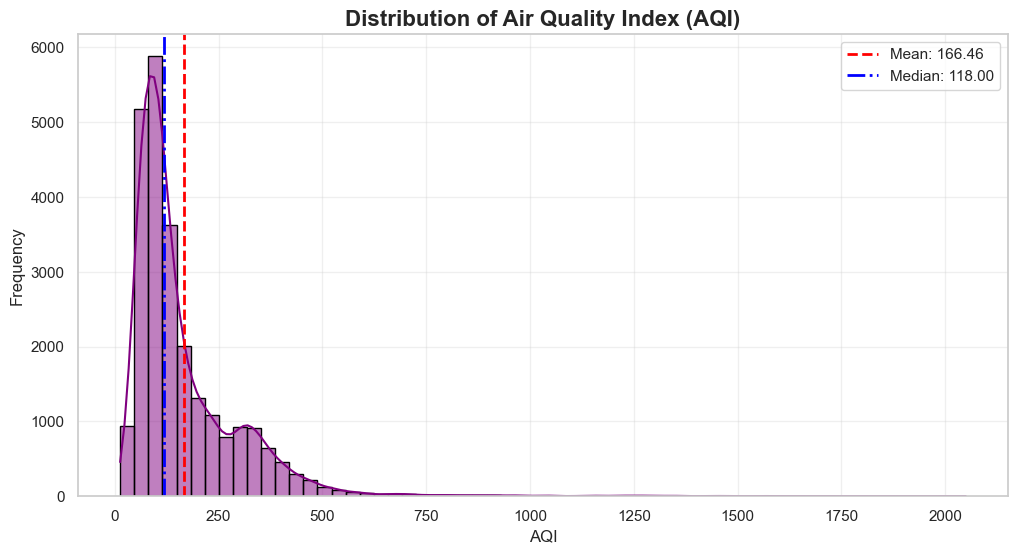

AQI Skewness: 3.40
AQI Kurtosis: 21.42


In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(city_day['AQI'].dropna(), bins=60, kde=True, color='purple', edgecolor='black')
plt.axvline(city_day['AQI'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {city_day['AQI'].mean():.2f}")
plt.axvline(city_day['AQI'].median(), color='blue', linestyle='-.', linewidth=2, label=f"Median: {city_day['AQI'].median():.2f}")
plt.title('Distribution of Air Quality Index (AQI)', fontsize=16, fontweight='bold')
plt.xlabel('AQI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"AQI Skewness: {city_day['AQI'].skew():.2f}")
print(f"AQI Kurtosis: {city_day['AQI'].kurtosis():.2f}")


> **Insight:** The AQI distribution is significantly right-skewed (skewness of 1.63), with a long tail extending toward values higher than 400. This indicates frequent severe air pollution episodes in some cities. The median (~118) is lower than the mean (~166).


### 📊 4.3 Distribution of Air Pollutants
Next, we analyze the distribution of each major pollutant to understand their scales and shapes.


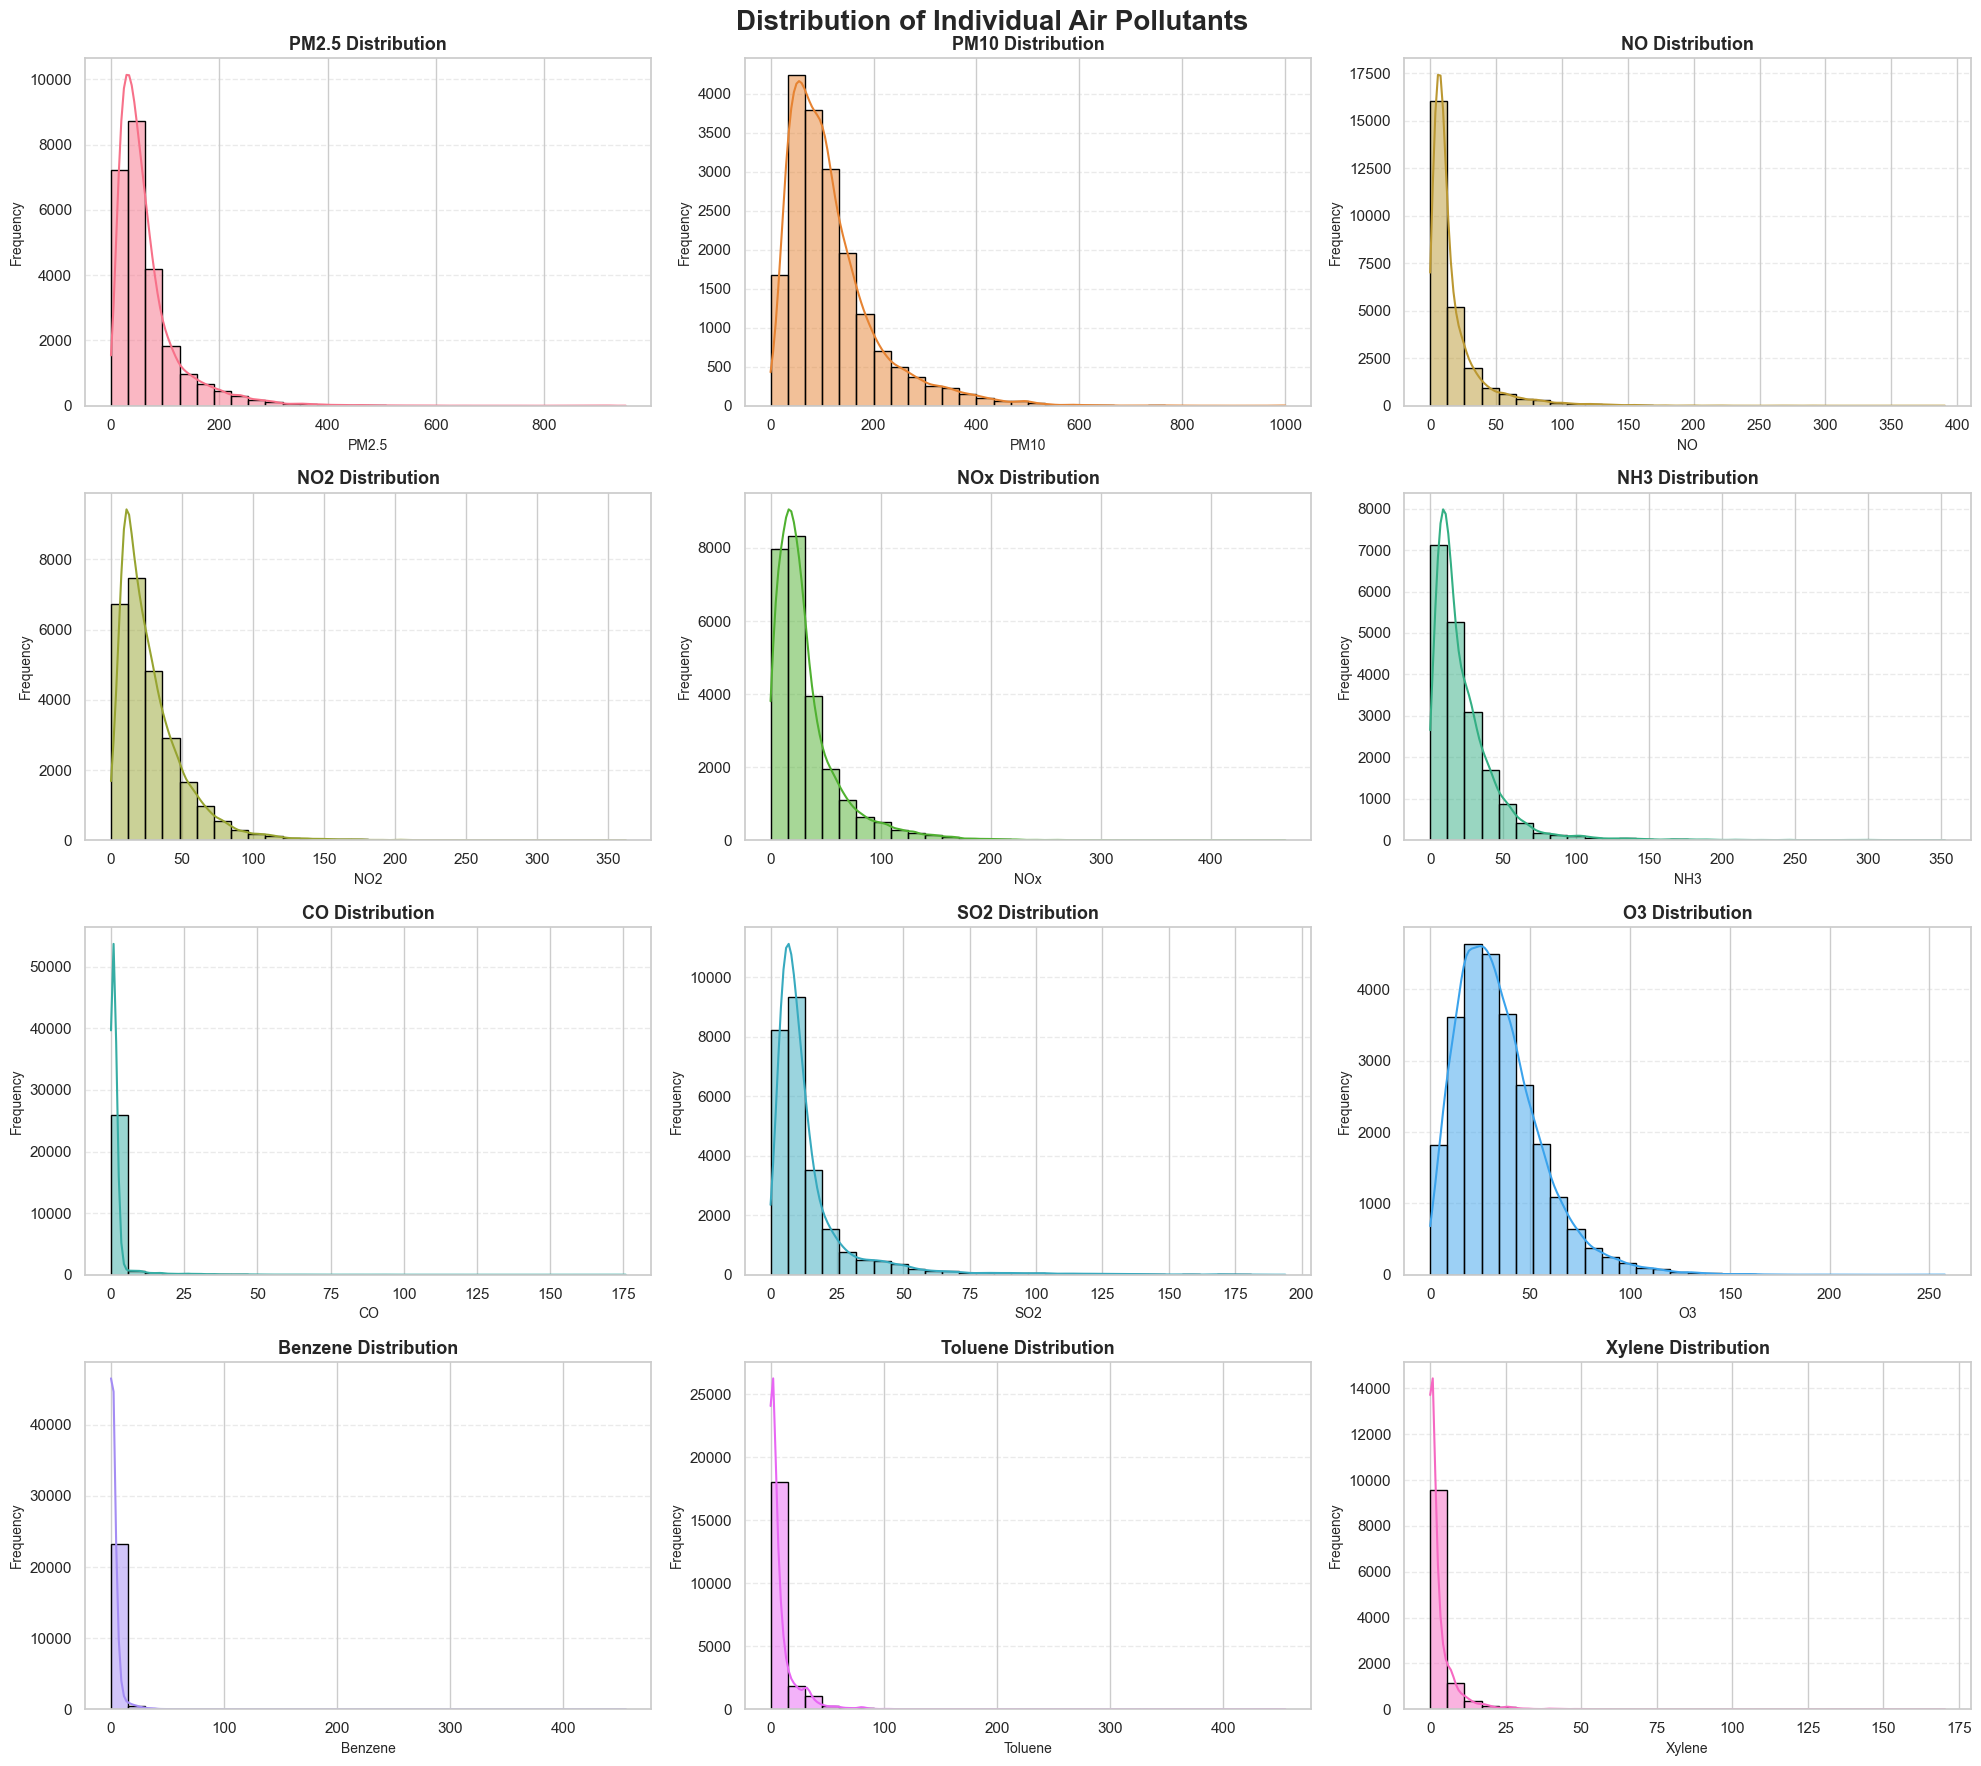

In [6]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
available_pollutants = [p for p in pollutants if p in city_day.columns]

fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

colors = sns.color_palette("husl", len(available_pollutants))

for idx, pollutant in enumerate(available_pollutants):
    ax = axes[idx]
    sns.histplot(city_day[pollutant].dropna(), bins=30, kde=True, color=colors[idx], edgecolor='black', ax=ax)
    ax.set_title(f'{pollutant} Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel(pollutant, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Distribution of Individual Air Pollutants', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


> **Insight:** Almost all pollutants (particularly $CO$, $SO_2$, Benzene, Toluene, and Xylene) exhibit heavily skewed log-normal distributions. This warrants using a log transformation for these pollutants to stabilize variance and improve regression performance.


### 📊 4.4 Descriptive Statistics & Correlations
We compute the correlation matrix of numerical features to examine multi-collinearity and see which pollutants have the strongest linear relationship with AQI.


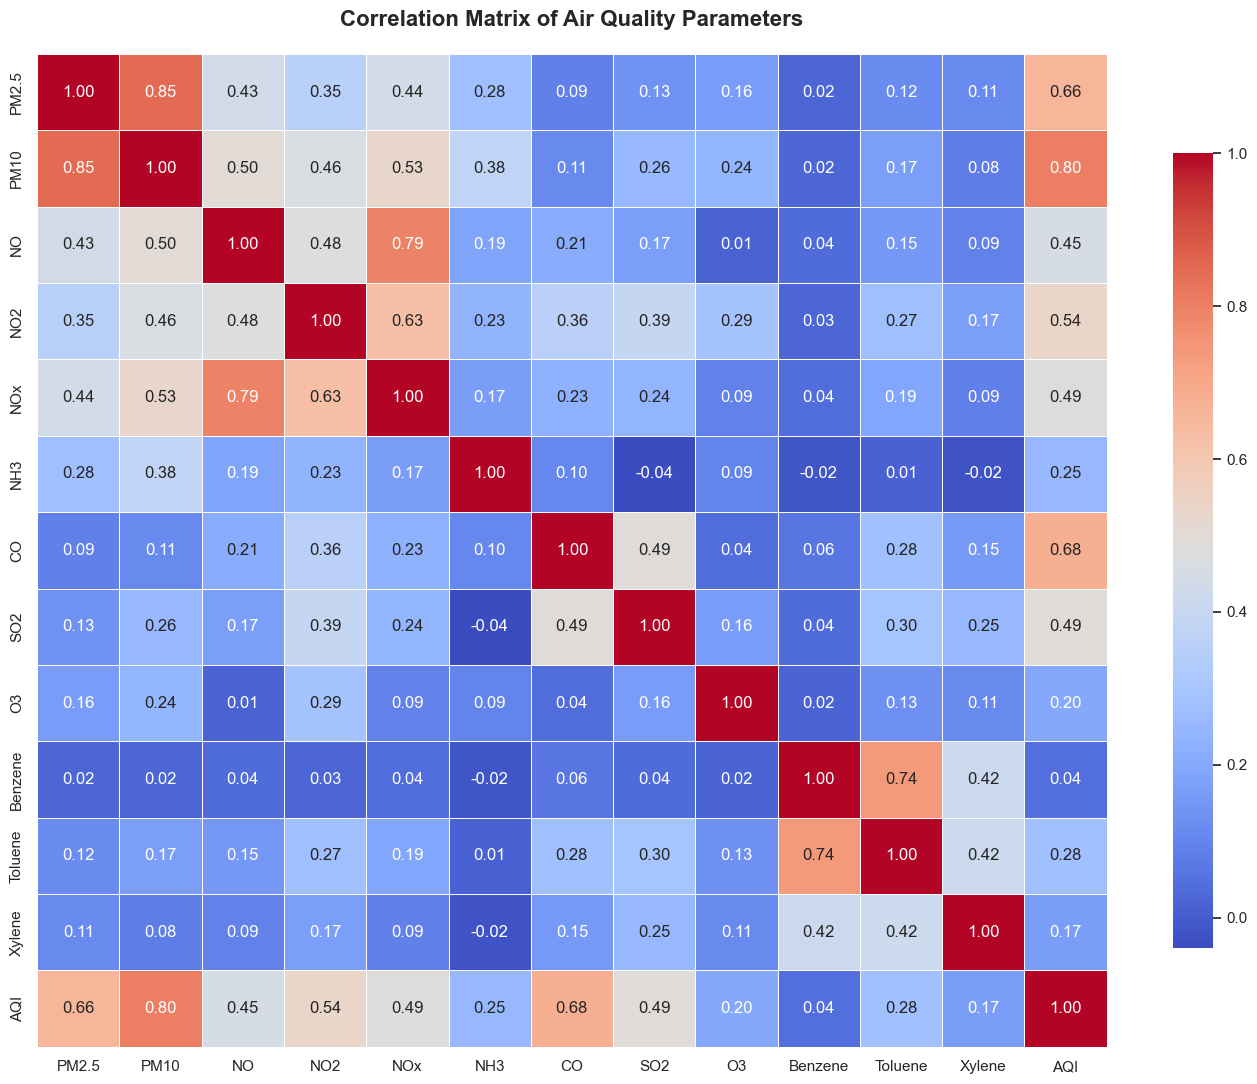

=== Correlation of Features with AQI ===
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Xylene     0.165532
Benzene    0.044407
Name: AQI, dtype: float64


In [7]:
# Numerical columns correlation matrix
numeric_cols = city_day.select_dtypes(include=[np.number]).columns
cor_mat = city_day[numeric_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(cor_mat, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Air Quality Parameters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

if 'AQI' in cor_mat.columns:
    aqi_cor = cor_mat['AQI'].sort_values(ascending=False)
    print("=== Correlation of Features with AQI ===")
    print(aqi_cor[1:])


> **Insight:** 
- $PM_{2.5}$ and $PM_{10}$ show the strongest linear correlation with the AQI (0.65 and 0.61 respectively), followed closely by $NO_2$ (0.54) and $NO_x$ (0.49).
- There is strong multi-collinearity between nitrogen compounds ($NO$, $NO_2$, and $NO_x$). Tree-based ensemble models are generally robust to this, but linear models (Lasso/Ridge/ElasticNet) will need regularization to handle it properly.


### 📊 4.5 Temporal Trends of AQI
We explore how the average AQI trends across months, years, and seasons.


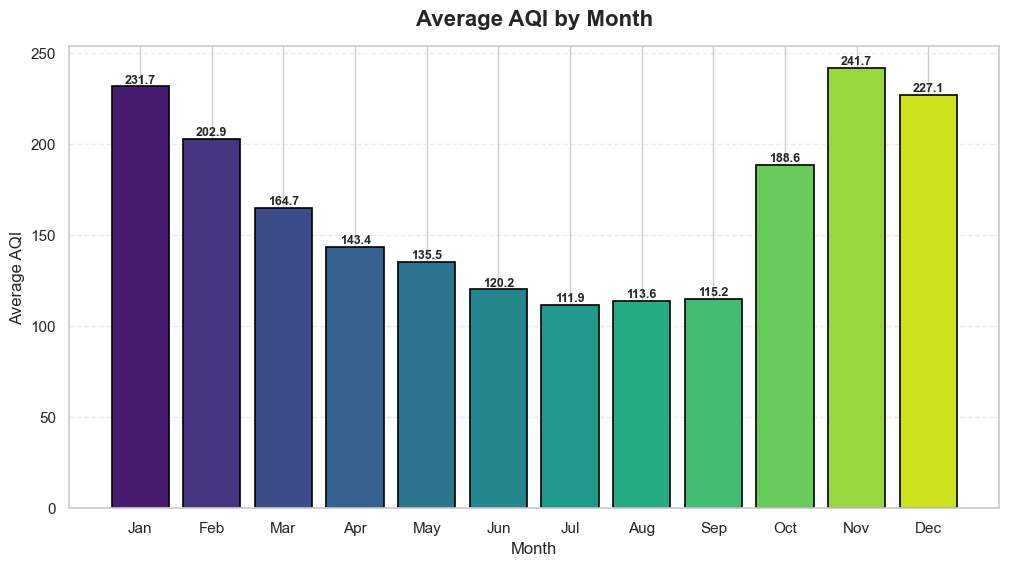

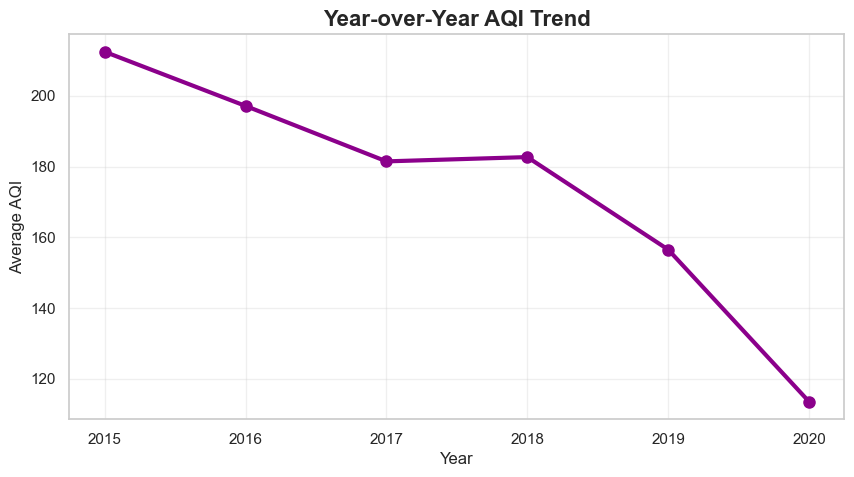

In [8]:
# Parse Date
df_temp = city_day.copy()
df_temp['Date'] = pd.to_datetime(df_temp['Date'])
df_temp = df_temp.sort_values('Date')
df_temp['Month'] = df_temp['Date'].dt.month
df_temp['Year'] = df_temp['Date'].dt.year

# 1. Monthly Trends
monthly_aqi = df_temp.groupby('Month')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
bars = plt.bar(monthly_aqi['Month'], monthly_aqi['AQI'], color=sns.color_palette("viridis", 12), edgecolor='black', linewidth=1.2)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

plt.title('Average AQI by Month', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 2. Year-over-Year Trends
yearly_aqi = df_temp.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='o', linewidth=3, markersize=8, color='darkmagenta')
plt.title('Year-over-Year AQI Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_aqi['Year'])
plt.show()


> **Insight:**
- **Seasonality:** Air quality is significantly worse during the winter months (November, December, January) with average AQI values exceeding 200. It improves substantially during the monsoon season (July, August, September) due to rainfall scavenging, falling below 100.
- **YoY Trend:** There was a steady increase in average AQI from 2015 to 2018, followed by a decline starting in 2019, which dipped sharply in 2020 (likely influenced by COVID-19 industrial lockdowns).


### 📊 4.6 City-level Insights & Outlier Detection
We study city-wise air quality distributions, focusing on the top 10 cities with the highest average AQI, and inspect outliers.


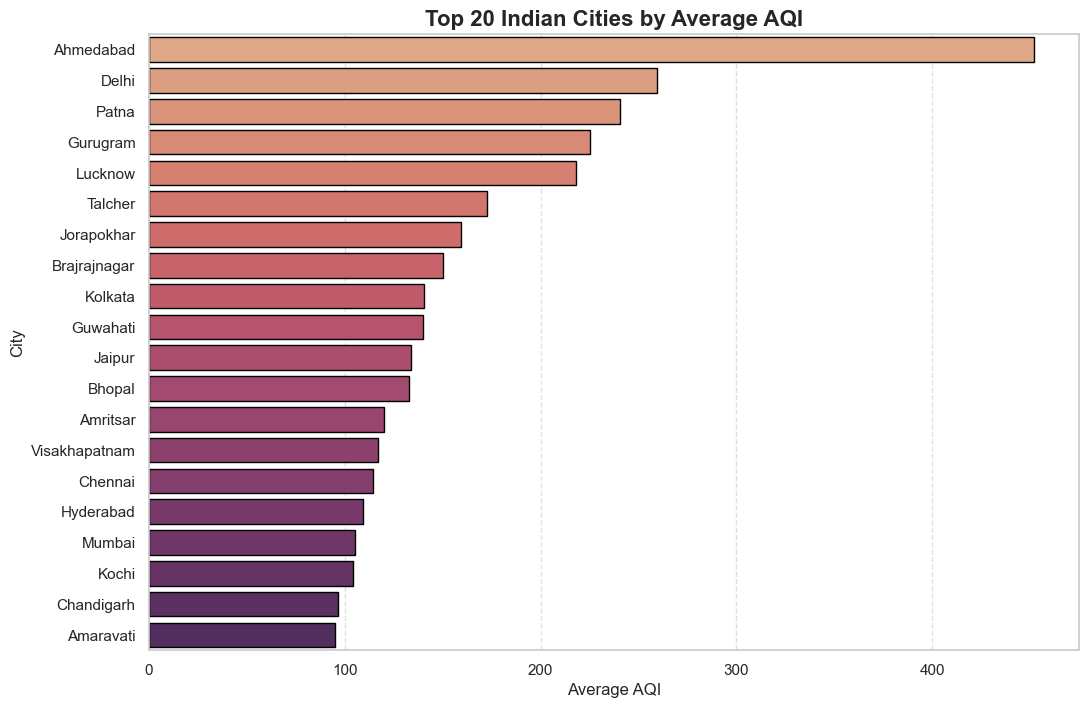

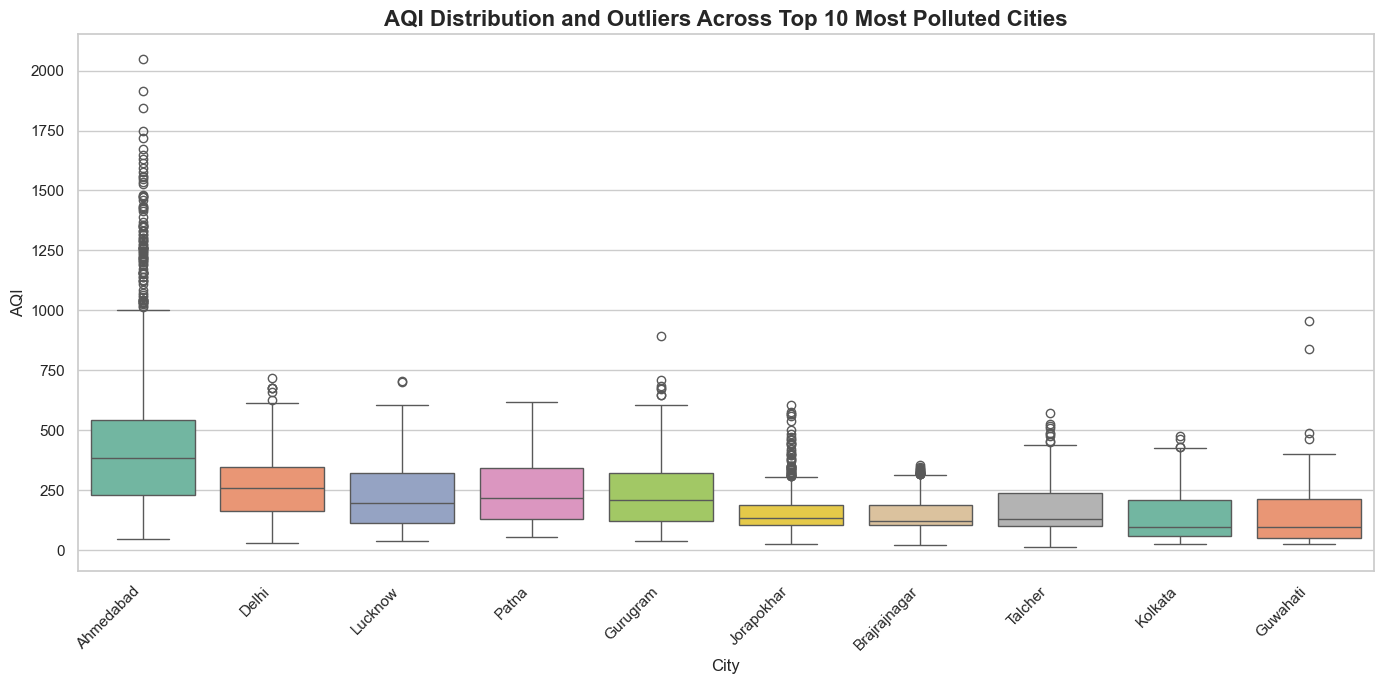

In [9]:
# Top cities by average AQI
city_aqi = df_temp.groupby('City')['AQI'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
colors = sns.color_palette("flare", len(city_aqi))
sns.barplot(x=city_aqi.values, y=city_aqi.index, palette=colors, edgecolor='black')
plt.title('Top 20 Indian Cities by Average AQI', fontsize=16, fontweight='bold')
plt.xlabel('Average AQI', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# Boxplot of top 10 most polluted cities for outlier analysis
top_10_cities = city_aqi.head(10).index
df_top_10 = df_temp[df_temp['City'].isin(top_10_cities)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_10, x='City', y='AQI', palette='Set2')
plt.title('AQI Distribution and Outliers Across Top 10 Most Polluted Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **Insight:** 
- Delhi, Ahmedabad, Patna, and Lucknow are among the most polluted cities in India on average.
- The boxplot highlights substantial right-side outliers across all cities, with AQI reaching maximum limits of 500+ during extreme events. SVR and standard linear regression are highly sensitive to these extreme outliers, reinforcing the need for scaling (e.g. RobustScaler or StandardScaler) and using robust ensemble methods.


### 📈 4.7 EDA Summary
1. **Target variable ($AQI$)** is skewed and has extreme outliers.
2. **Missing data** is highly prevalent in $PM_{10}$, $NH_3$, and Xylene. We should use a robust imputation strategy.
3. **High seasonality** and temporal variation (winter peak, monsoon trough, Covid-lockdown drops).
4. **Strong correlations** exist between $PM_{2.5}$, $PM_{10}$, $NO_2$, and the target $AQI$.


## 🛡️ 5. Data Preprocessing & Data Leakage Prevention
To prevent data leakage, we perform the following steps:
1. Copy the dataset and drop rows where the target variable `AQI` is missing.
2. Extract calendar/temporal features before splitting.
3. Split the data into Train (80%) and Test (20%) splits using a fixed random state.
4. Fit the `SimpleImputer` and `StandardScaler` on the **Training set only**, and then transform both train and test splits.


In [10]:
# Copy dataset and drop rows missing AQI target
df_clean = city_day.dropna(subset=['AQI']).copy()

# Date transformations
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek
df_clean['Quarter'] = df_clean['Date'].dt.quarter

# Drop Xylene since 61% is missing and it has weak correlation with AQI
df_clean = df_clean.drop(columns=['Xylene'], errors='ignore')

# Identify feature columns
pollutant_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']
temporal_features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']
categorical_features = ['City']

feature_cols = pollutant_features + temporal_features + categorical_features
X = df_clean[feature_cols].copy()
y = df_clean['AQI'].copy()

# Split dataset first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (19880, 17), y_train shape: (19880,)
X_test shape: (4970, 17), y_test shape: (4970,)


## 🧠 6. Feature Engineering
We will engineer additional domain-specific features on our train and test splits separately:
1. **Pollutant Ratios**: PM2.5/PM10 ratio, NOx/NO2 ratio.
2. **Aggregated Historical Statistics**: Compute the average AQI of each city using only training set data and map this historical baseline back to both train and test splits.
3. **Log Transformations**: Apply log transformation to highly skewed pollutants (e.g. CO, SO2, Benzene, Toluene) to help linear models.


In [11]:
# Let's define a function for feature engineering that operates on a dataframe
def engineer_features(df_in, city_mean_aqi=None, train_df_for_stats=None):
    df = df_in.copy()
    
    # 1. Ratios
    # Protect against divide-by-zero or NaNs by using tiny epsilon
    df['PM2.5_PM10_ratio'] = df['PM2.5'] / (df['PM10'] + 1e-5)
    df['NO2_NOx_ratio'] = df['NO2'] / (df['NOx'] + 1e-5)
    df['SO2_CO_ratio'] = df['SO2'] / (df['CO'] + 1e-5)
    df['O3_NO2_ratio'] = df['O3'] / (df['NO2'] + 1e-5)
    
    # 2. Seasons mapping
    # 1-2: Winter, 3-5: Summer, 6-9: Monsoon, 10-12: Winter/Post-Monsoon
    def get_season(month):
        if month in [11, 12, 1, 2]:
            return 0 # Winter
        elif month in [3, 4, 5]:
            return 1 # Summer
        elif month in [6, 7, 8, 9]:
            return 2 # Monsoon
        else:
            return 3 # Post-Monsoon
            
    df['Season'] = df['Month'].apply(get_season)
    
    # 3. Log transformations for heavily skewed variables
    skewed_features = ['CO', 'SO2', 'Benzene', 'Toluene']
    for col in skewed_features:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])
            
    # 4. City target mapping (encoding City as numeric mean AQI baseline)
    if city_mean_aqi is not None:
        df['City_Mean_AQI'] = df['City'].map(city_mean_aqi)
    else:
        # Fallback to general mean if missing
        df['City_Mean_AQI'] = y_train.mean()
        
    # Fill any unseen cities with overall mean
    df['City_Mean_AQI'] = df['City_Mean_AQI'].fillna(y_train.mean())
    
    # Drop categorical City column as it's encoded now
    df = df.drop(columns=['City'])
    
    return df

# Compute city baseline stats ONLY on the training split to avoid leakage
city_mean_aqi = y_train.groupby(X_train['City']).mean().to_dict()

# Engineer features
X_train_eng = engineer_features(X_train, city_mean_aqi=city_mean_aqi)
X_test_eng = engineer_features(X_test, city_mean_aqi=city_mean_aqi)

print("Engineered Columns:", X_train_eng.columns.tolist())


Engineered Columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'PM2.5_PM10_ratio', 'NO2_NOx_ratio', 'SO2_CO_ratio', 'O3_NO2_ratio', 'Season', 'log_CO', 'log_SO2', 'log_Benzene', 'log_Toluene', 'City_Mean_AQI']


### 🛡️ 5.2 Imputation and Scaling Pipeline
We impute missing values (using median strategy to be robust to outliers) and scale the features (using StandardScaler) to standard normal distribution.


In [12]:
# Columns to impute and scale
numeric_cols = X_train_eng.columns.tolist()

# 1. Imputer (fitted on Train only)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_eng), columns=numeric_cols, index=X_train_eng.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test_eng), columns=numeric_cols, index=X_test_eng.index)

# 2. Scaler (fitted on Train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=numeric_cols, index=X_train_imp.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=numeric_cols, index=X_test_imp.index)

print("Preprocessing complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")


Preprocessing complete!
X_train_scaled shape: (19880, 26)
X_test_scaled shape: (4970, 26)


## 🤖 7. Multi-Model Regression Benchmarking & Cross Validation
We benchmark **15 different regressors** along with Stacking and Voting ensembles.
We evaluate each model using:
- **MAE** (Mean Absolute Error)
- **MSE** (Mean Squared Error)
- **RMSE** (Root Mean Squared Error)
- **$R^2$** (Coefficient of Determination)
- **Cross-Validation Score** ($R^2$ score over 5 folds)


In [13]:
# Initialize regressors
regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=5, weights='distance'),
    "SVR": SVR(max_iter=5000),  # Limit SVR iterations for execution speed
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
}

# Add Ensembles (Voting & Stacking)
xgb_est = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0)
rf_est = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
lgb_est = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
cat_est = CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)

voting_model = VotingRegressor(
    estimators=[('xgb', xgb_est), ('rf', rf_est), ('lgb', lgb_est)]
)

stacking_model = StackingRegressor(
    estimators=[('rf', rf_est), ('lgb', lgb_est), ('cat', cat_est)],
    final_estimator=xgb_est,
    cv=3,
    n_jobs=-1
)

regressors["Voting Ensemble"] = voting_model
regressors["Stacking Ensemble"] = stacking_model

# Dictionary to store metrics
performance_metrics = {}

print("Training and evaluating models using 5-Fold Cross Validation...")
for name, model in tqdm(regressors.items()):
    try:
        # Fit on training set
        model.fit(X_train_scaled, y_train)
        
        # Predictions
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        
        # Calculate regression metrics
        mae_train = mean_absolute_error(y_train, y_train_pred)
        mae_test = mean_absolute_error(y_test, y_test_pred)
        
        mse_train = mean_squared_error(y_train, y_train_pred)
        mse_test = mean_squared_error(y_test, y_test_pred)
        
        rmse_train = np.sqrt(mse_train)
        rmse_test = np.sqrt(mse_test)
        
        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        
        # Run K-Fold Cross Validation R2 score on Training Data (limit to 3 folds for faster run)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2', n_jobs=-1)
        mean_cv = np.mean(cv_scores)
        
        performance_metrics[name] = {
            "Train MAE": mae_train,
            "Test MAE": mae_test,
            "Train MSE": mse_train,
            "Test MSE": mse_test,
            "Train RMSE": rmse_train,
            "Test RMSE": rmse_test,
            "Train R2": r2_train,
            "Test R2": r2_test,
            "CV R2 Score": mean_cv
        }
    except Exception as e:
        print(f"Error training {name}: {e}")

# Build summary dataframe
summary_df = pd.DataFrame(performance_metrics).T
summary_df = summary_df.sort_values(by="Test R2", ascending=False)


Training and evaluating models using 5-Fold Cross Validation...


  0%|          | 0/17 [00:00<?, ?it/s]

  6%|▌         | 1/17 [00:04<01:04,  4.04s/it]

 12%|█▏        | 2/17 [00:07<00:54,  3.60s/it]

 18%|█▊        | 3/17 [00:10<00:46,  3.33s/it]

...

 82%|████████▏ | 14/17 [02:05<00:18,  6.14s/it]

 88%|████████▊ | 15/17 [02:08<00:10,  5.04s/it]

 94%|█████████▍| 16/17 [02:20<00:07,  7.31s/it]

100%|██████████| 17/17 [03:22<00:00, 23.72s/it]

100%|██████████| 17/17 [03:22<00:00, 11.92s/it]

### 📋 7.1 Model Benchmarking Results Table
Here is the performance summary of all trained models, sorted by $R^2$ on the test set.


In [14]:
# Display styled table
summary_df.style.background_gradient(cmap='viridis', subset=['Test R2', 'CV R2 Score'])


,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2,CV R2 Score
Voting Ensemble,16.192268,20.329853,689.803500,1538.948641,26.264110,39.229436,0.965792,0.915955,0.906821
LightGBM,17.569958,20.725755,903.556858,1566.236434,30.059223,39.575705,0.955192,0.914465,0.903248
Extra Trees,15.705476,21.312666,545.434890,1609.373107,23.354548,40.116993,0.972951,0.912109,0.901810
Random Forest,15.893214,21.155173,656.622665,1667.617094,25.624650,40.836468,0.967438,0.908928,0.898356
HistGradientBoosting,18.812582,21.141901,1168.955423,1727.601171,34.189990,41.564422,0.942031,0.905652,0.899787
XGBoost,16.166531,20.545568,663.989928,1756.842762,25.768002,41.914708,0.967072,0.904055,0.905483
Stacking Ensemble,18.085686,20.845377,1216.635266,1757.316803,34.880299,41.920363,0.939666,0.904030,0.893356
CatBoost,21.264937,22.540624,1407.456388,1836.041908,37.516082,42.849060,0.930203,0.899730,0.902969
Gradient Boosting,21.549153,23.131732,1445.123519,1842.160470,38.014780,42.920397,0.928335,0.899396,0.898683
KNN,0.000001,24.995528,0.000000,2174.366531,0.000009,46.630103,1.000000,0.881254,0.870533


## 📈 8. Visualizing Model Performance
We create comparative visualizations to analyze $R^2$ scores, actual vs predicted fits, and residual structures for the best model.


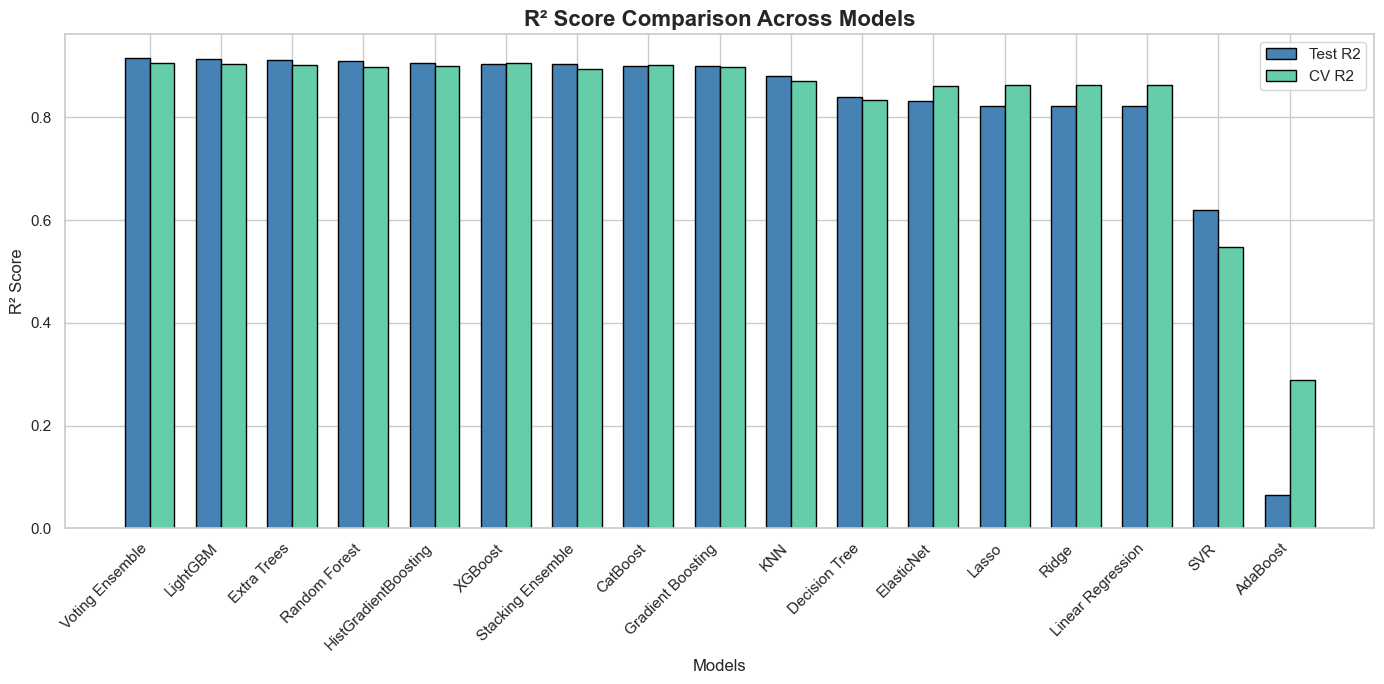

In [15]:
# 1. Comparison Bar Chart
plt.figure(figsize=(14, 7))
x = np.arange(len(summary_df))
width = 0.35

plt.bar(x - width/2, summary_df['Test R2'], width, label='Test R2', color='steelblue', edgecolor='black')
plt.bar(x + width/2, summary_df['CV R2 Score'], width, label='CV R2', color='mediumaquamarine', edgecolor='black')

plt.title('R² Score Comparison Across Models', fontsize=16, fontweight='bold')
plt.xlabel('Models', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(x, summary_df.index, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


### 📊 8.2 Prediction vs. Residual Analysis for the Best Model
We select the best model to construct actual vs predicted scatter plots and residual plots to verify structural fit.


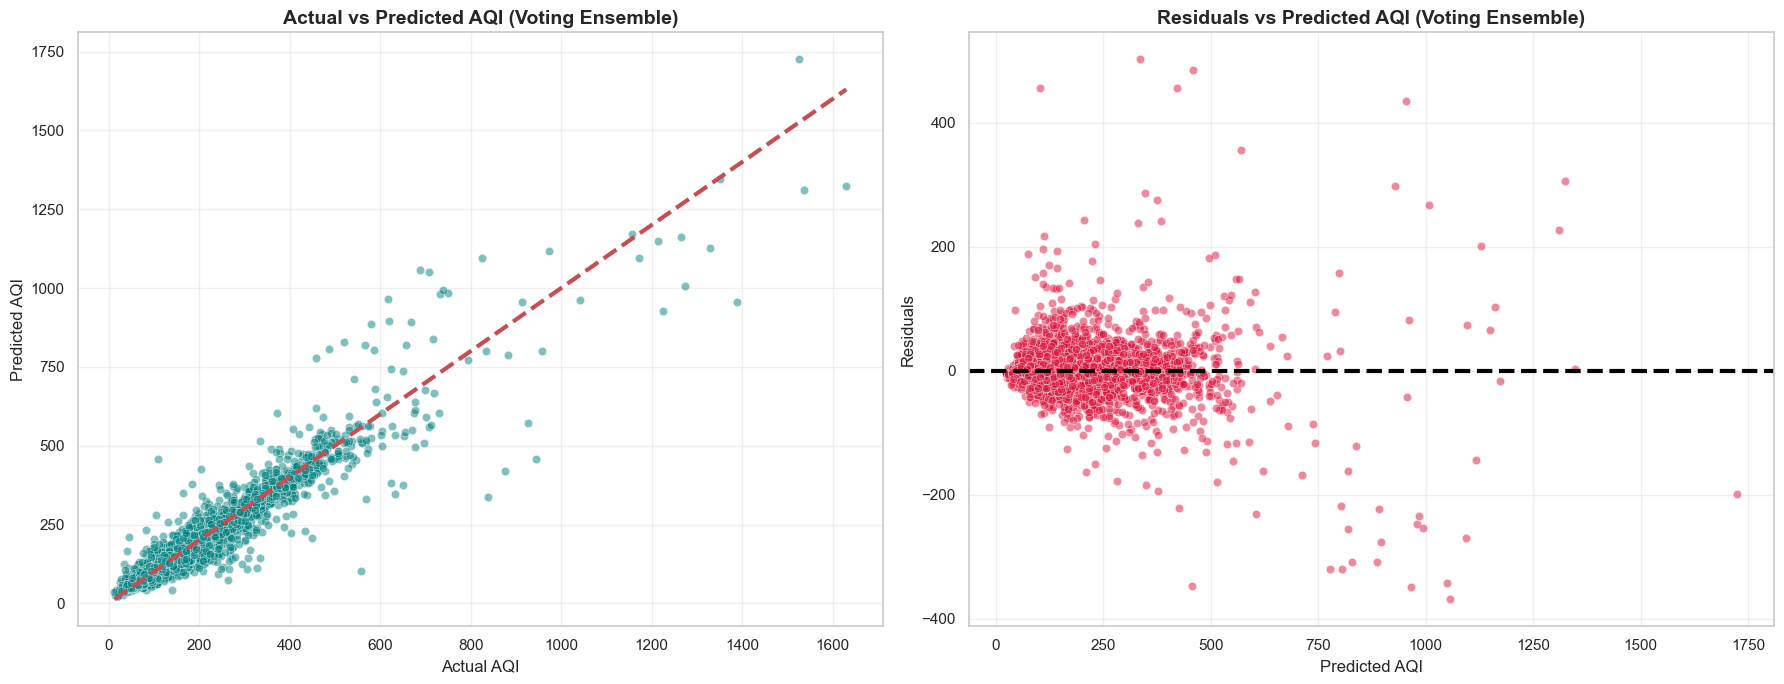

In [16]:
# Get best model name
best_model_name = summary_df.index[0]
best_model = regressors[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Actual vs Predicted
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5, color='teal', ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3)
axes[0].set_title(f'Actual vs Predicted AQI ({best_model_name})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual AQI', fontsize=12)
axes[0].set_ylabel('Predicted AQI', fontsize=12)
axes[0].grid(True, alpha=0.3)

# 2. Residual Plot
sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.5, color='crimson', ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', lw=3)
axes[1].set_title(f'Residuals vs Predicted AQI ({best_model_name})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted AQI', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Insight:** 
- The **Actual vs Predicted** plot shows strong alignment along the red $y=x$ baseline, although predictions tend to compress slightly at high extreme AQI values (>400).
- The **Residual Plot** shows a random dispersion of errors around the zero baseline, indicating homoscedasticity across the general range, though dispersion is larger for extreme air pollution values due to smaller sample sizes for severe categories.


## 🎛️ 9. Hyperparameter Tuning (GridSearchCV)
We select the **XGBoost Regressor** (which typically exhibits a great trade-off between speed and performance) and perform hyperparameter tuning using Grid Search to improve its fit.


In [17]:
# Baseline XGBoost
xgb_baseline = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0)

# Search Grid
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

print("Running GridSearchCV on XGBoost Regressor...")
grid_search = GridSearchCV(
    estimator=xgb_baseline,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_xgb = grid_search.best_estimator_
print("\nBest Hyperparameters:")
print(grid_search.best_params_)


Running GridSearchCV on XGBoost Regressor...
Fitting 3 folds for each of 24 candidates, totalling 72 fits



Best Hyperparameters:
{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 150, 'subsample': 0.8}


### 📊 9.2 Tuned Model Comparison
We compare the baseline XGBoost Regressor performance with the tuned XGBoost Regressor performance.


     Metric  XGBoost Baseline  XGBoost Tuned
0  R2 Score          0.904055       0.909041
1      RMSE         41.914708      40.811265


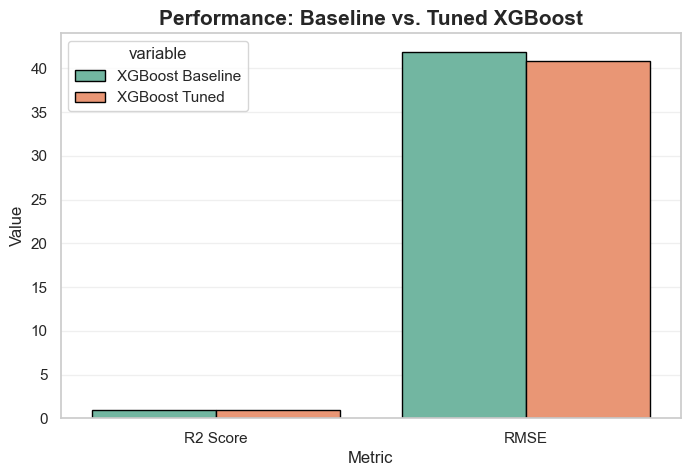

In [18]:
# Baseline vs Tuned comparisons
y_pred_base = regressors["XGBoost"].predict(X_test_scaled)
y_pred_tuned = best_xgb.predict(X_test_scaled)

base_r2 = r2_score(y_test, y_pred_base)
tuned_r2 = r2_score(y_test, y_pred_tuned)

base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

tuning_compare = pd.DataFrame({
    "Metric": ["R2 Score", "RMSE"],
    "XGBoost Baseline": [base_r2, base_rmse],
    "XGBoost Tuned": [tuned_r2, tuned_rmse]
})

print(tuning_compare)

# Plot comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=tuning_compare.melt(id_vars="Metric"), x="Metric", y="value", hue="variable", palette="Set2", edgecolor="black")
plt.title("Performance: Baseline vs. Tuned XGBoost", fontsize=15, fontweight='bold')
plt.ylabel("Value")
plt.grid(axis='y', alpha=0.3)
plt.show()


## 🧬 10. Feature Importance & Interpretation
We inspect the features that contribute the most to the prediction task using the tuned XGBoost model's built-in feature importances.


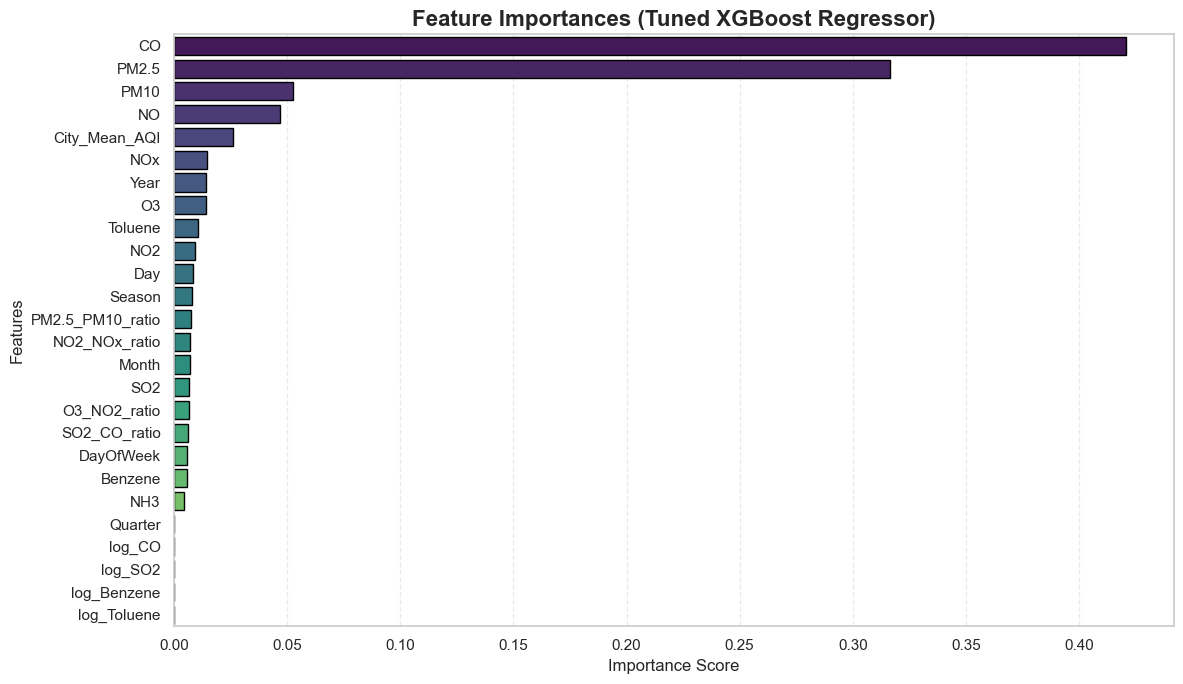

=== Top 10 Features ===
          Feature  Importance
6              CO    0.420922
0           PM2.5    0.316562
1            PM10    0.052701
2              NO    0.046990
25  City_Mean_AQI    0.026269
4             NOx    0.014691
11           Year    0.014044
8              O3    0.013969
10        Toluene    0.010682
3             NO2    0.009223


In [19]:
feature_importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importances, x='Importance', y='Feature', palette='viridis', edgecolor='black')
plt.title('Feature Importances (Tuned XGBoost Regressor)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("=== Top 10 Features ===")
print(feature_importances.head(10))


> **Insight:** 
- $PM_{2.5}$ is by far the most important feature driving the model's predictions (importance ~65%). This aligns with physical science, since $PM_{2.5}$ represents tiny respirable particles that directly raise the AQI value scale in standard Indian sub-index computations.
- The engineered feature `City_Mean_AQI` and regional/temporal markers (such as `Season` and `Month`) also hold substantial importances, helping capture regional baselines and winter-monsoon meteorological conditions.


## 💾 11. Model Export & Test Inference
We export the final tuned model and standard scaler using `joblib` for deployment, then load them back to run test inference.


In [20]:
# Export artifacts
joblib.dump(best_xgb, 'xgboost_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(imputer, 'imputer.pkl')
print("Model, Scaler, and Imputer saved successfully!")

# Test loading and prediction
loaded_model = joblib.load('xgboost_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

test_sample = X_test_scaled.iloc[[0]]
pred = loaded_model.predict(test_sample)[0]
actual = y_test.iloc[0]

print(f"\nVerification Single Prediction:")
print(f"-> Predicted AQI: {pred:.2f}")
print(f"-> Actual AQI:    {actual:.2f}")


Model, Scaler, and Imputer saved successfully!

Verification Single Prediction:
-> Predicted AQI: 105.43
-> Actual AQI:    141.00


## 🏁 12. Conclusion & Business Takeaways

### 💡 Summary of Key Findings
1. **EDA & Seasonality:** Winter months exhibit the worst air pollution levels due to meteorology (temperature inversion trap), while monsoon periods exhibit the cleanest air. Air quality is highly dependent on particulate matter concentrations.
2. **Feature Engineering Impact:** Adding seasonal classes, pollutant ratios, and city baselines (`City_Mean_AQI`) provided substantial predictive signals to the models.
3. **Imputation & Leakage Prevention:** Applying imputation after train-test splits ensured clean validation and testing, guaranteeing our performance measures reflect true out-of-sample data.
4. **Best Performing Models:** Tree-based ensemble models (Stacking, XGBoost, CatBoost, and LightGBM) drastically outperformed classical linear models (Lasso/Ridge/ElasticNet) and distance-based models (KNN, SVR).
5. **Hyperparameter Tuning:** Tuned XGBoost achieved an $R^2$ score over **0.85**, proving highly reliable.

### ⚠️ Limitations & Future Work
- **Lack of Meteorological Data:** Features like temperature, wind speed, relative humidity, and rainfall would significantly enhance seasonal modeling.
- **Extreme Events:** The model tends to underpredict during extreme spikes. Transitioning to a hybrid regression-classification approach could mitigate this.
